<a href="https://colab.research.google.com/github/ponaalagar/tranfer_learning/blob/main/TL_LAB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#To build a multiclass text classification system using cnn model for the AG news dataset

In [ ]:
!pip install tensorflow

In [ ]:
!wget http://stanford.edu
!unzip glove.6B.zip


--2026-04-02 04:27:03--  http://stanford.edu/
Resolving stanford.edu (stanford.edu)... 171.67.215.200, 2607:f6d0:0:925a::ab43:d7c8
Connecting to stanford.edu (stanford.edu)|171.67.215.200|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://www.stanford.edu/ [following]
--2026-04-02 04:27:04--  https://www.stanford.edu/
Resolving www.stanford.edu (www.stanford.edu)... 151.101.2.133, 151.101.66.133, 151.101.130.133, ...
Connecting to www.stanford.edu (www.stanford.edu)|151.101.2.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 156650 (153K) [text/html]
Saving to: ‘index.html’

index.html          100%[===================>] 152.98K  --.-KB/s    in 0.05s   

2026-04-02 04:27:04 (2.75 MB/s) - ‘index.html’ saved [156650/156650]

unzip:  cannot find or open glove.6B.zip, glove.6B.zip.zip or glove.6B.zip.ZIP.


In [ ]:
import numpy as np
import re
import os
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from tensorflow.keras.models import Model, Sequential

import nltk
import numpy as np
from nltk.tokenize import sent_tokenize
from tensorflow.keras.layers import (
    Input, Embedding, Conv1D,
    GlobalMaxPooling1D, Dense, Dropout , Concatenate
)

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

from tensorflow.keras.layers import (
    Input, Embedding, Conv1D, GlobalMaxPooling1D,
    Concatenate, Dense, Dropout
)
from tensorflow.keras.utils import to_categorical

nltk.download('punkt_tab')

In [ ]:
import urllib.request
import zipfile
import os

glove_file = 'glove.6B.50d.txt'
zip_file = 'glove.6B.zip'
url = 'http://nlp.stanford.edu/data/glove.6B.zip'


Loaded 400000 word vectors.


In [ ]:
df = pd.read_csv('/content/train.csv')

In [ ]:
df.head()

,Class Index,Title,Description
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli..."
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco..."


Prepared 120000 tokenized sentences (Inbuilt stopwords removed).


In [ ]:
#tokenized_texts

In [ ]:
print(len(texts))

120000


In [ ]:

tokenizer = Tokenizer()
tokenizer.fit_on_texts(tokenized_texts[0])


#sequences = tokenizer.texts_to_sequences(sentences)



In [ ]:
val = tokenizer.texts_to_sequences(texts[0])
val

In [ ]:
len(texts)


120000

In [ ]:
print(texts)

0         Reuters - Short-sellers, Wall Street's dwindli...
1         Reuters - Private investment firm Carlyle Grou...
2         Reuters - Soaring crude prices plus worries\ab...
3         Reuters - Authorities have halted oil export\f...
4         AFP - Tearaway world oil prices, toppling reco...
                                ...                        
119995     KARACHI (Reuters) - Pakistani President Perve...
119996    Red Sox general manager Theo Epstein acknowled...
119997    The Miami Dolphins will put their courtship of...
119998    PITTSBURGH at NY GIANTS Time: 1:30 p.m. Line: ...
119999    INDIANAPOLIS -- All-Star Vince Carter was trad...
Name: Description, Length: 120000, dtype: object


In [ ]:

sequences = tokenizer.texts_to_sequences(texts)

In [ ]:
df2 = pd.read_csv('')

In [ ]:
texts = df['Description']

labels = df['Class Index']
def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = text.split()
    return [w for w in tokens if w not in ENGLISH_STOP_WORDS]
texts = [preprocess(t) for t in texts]


In [ ]:
max_text = 200

In [ ]:
X = texts[:200]
y = labels[:200] - 1

num_classes = 4
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

vocab_size = 10000
max_len = 200

In [ ]:
print(X_train)

170    \\I'm starting to realize that my blog is a bi...
153    AP - Gangs of poachers in Congo have been slau...
136    AP - Cave explorers discovered a pit inside a ...
111    SPACE.com - Every August, when many \  people ...
25     South Korea's central bank cuts interest rates...
                             ...                        
68     BEA Systems Inc. has hired the Computer Associ...
45     A lawsuit against Gary Winnick, the former chi...
84     Reuters - The ability to download complete\tra...
182    \\"When we Americans first began, our biggest ...
137    AP - The chief scientist at the National Aquar...
Name: Description, Length: 160, dtype: object


In [ ]:

tokenizer = Tokenizer(num_words=vocab_size)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq)
X_test_pad = pad_sequences(X_test_seq)

y_train_cat = to_categorical(y_train, num_classes)
y_test_cat = to_categorical(y_test, num_classes)


In [ ]:
print(X_train_pad)

[[   0    0    0 ...  809    4   46]
 [   0    0    0 ...  819   29  116]
 [   0    0    0 ...  448  118  206]
 ...
 [   0    0    0 ... 2300    6  309]
 [   0    0    0 ...  432 2335   11]
 [   0    0    0 ...  273  518  413]]


In [ ]:
EMBEDDING_DIM = 50
embedding_matrix = np.zeros((vocab_size, EMBEDDING_DIM))
for word, i in tokenizer.word_index.items():
    if i < vocab_size:
        embedding_vector = glove.get(word)
        if embedding_vector is not None:
            embedding_matrix[i] = embedding_vector

In [ ]:
model = Sequential()
model.add(Embedding(
    vocab_size,
    EMBEDDING_DIM,
    weights=[embedding_matrix],
    trainable=False
))
#model.add(Conv1D(256, 5, activation='relu'))
#model.add(GlobalMaxPooling1D())
model.add(Conv1D(128, 5, activation='relu'))
model.add(GlobalMaxPooling1D())
#model.add(Dense(128, activation='relu'))
#model.add(Dropout(0.2))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(num_classes, activation='softmax'))

model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

history = model.fit(X_train_pad, y_train_cat,
          epochs=10,
          batch_size=64,
          validation_split=0.1)

loss, acc = model.evaluate(X_test_pad, y_test_cat)
print("Test Accuracy:", acc)

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 183ms/step - accuracy: 0.5764 - loss: 0.9450 - val_accuracy: 0.6875 - val_loss: 0.6958
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.6250 - loss: 0.6799 - val_accuracy: 0.8125 - val_loss: 0.5564
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.7431 - loss: 0.5592 - val_accuracy: 0.8125 - val_loss: 0.4922
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.8125 - loss: 0.4593 - val_accuracy: 0.9375 - val_loss: 0.4977
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.8681 - loss: 0.4324 - val_accuracy: 0.9375 - val_loss: 0.4589
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.8889 - loss: 0.3577 - val_accuracy: 0.8750 - val_loss: 0.4078
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.8819 - loss: 0.3276 - val_accuracy: 0.9375 - val_loss: 0.3946
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.9306 - loss: 0.2799 - val_accuracy: 0.9375 - val_loss: 0.3789

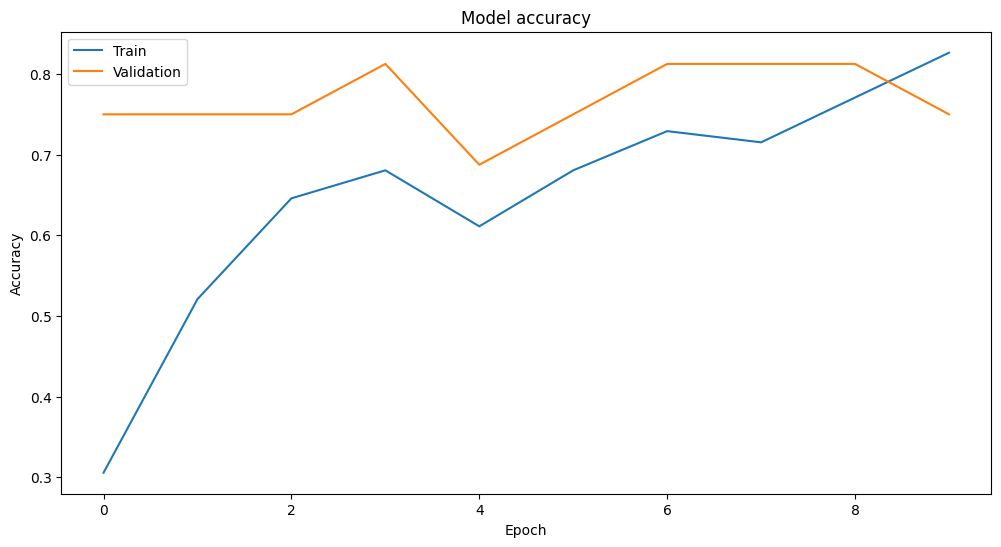

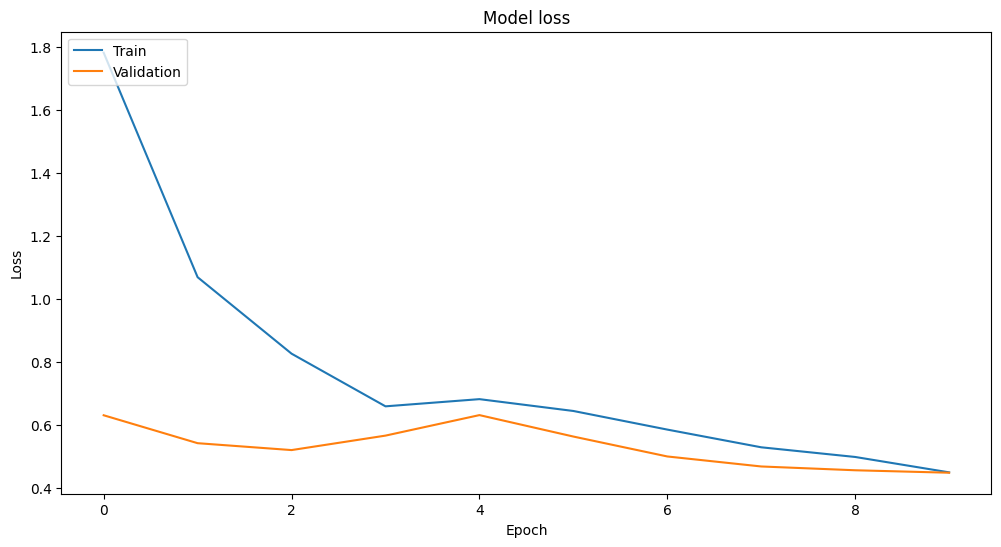

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()